In [1]:
import os
import numpy as np
import pandas as pd

In [2]:
from libcbm import resources
from libcbm.model.moss_c import model_context_factory
from libcbm.model.moss_c import model
from libcbm.model.moss_c import pools

In [3]:
data_dir = os.path.join(
   resources.get_test_resources_dir(),
    "moss_c_multiple_stands")

In [4]:
ctx = model_context_factory.create_from_csv(data_dir)

In [5]:
model.spinup(ctx)

In [6]:
pools_by_timestep = pd.DataFrame()
flux_by_timestep = pd.DataFrame()

In [7]:
mean_annual_temps = np.full(ctx.pools.n_rows, 11.1)
pools_0 = ctx.pools.to_pandas().copy()
pools_0.insert(0, "t", 0)
pools_by_timestep = pd.concat([pools_by_timestep,pools_0])

for t in range(1,100):
    if t == 20:
        # disturb everything to demonstrate how this works
        ctx.state["disturbance_type"].assign(1)
    else:
        ctx.state["disturbance_type"].assign(0)
    ctx.parameters["mean_annual_temp"].assign(mean_annual_temps)
    model.step(ctx)

    pools_t = ctx.pools.to_pandas().copy()
    pools_t.insert(0, "t", t)
    pools_by_timestep = pd.concat([pools_by_timestep, pools_t])

    flux_t = ctx.flux.to_pandas().copy()
    flux_t.insert(0, "t", t)
    flux_by_timestep = pd.concat([flux_by_timestep, flux_t])


In [8]:
ctx.parameters.to_pandas()

,moss_c_parameter_id,merch_volume_id,decay_parameter_id,mean_annual_temperature_id,spinup_parameter_id,historical_disturbance_type_id,last_pass_disturbance_type_id,area,age,a,...,n,q10,tref,kff,ksf,kfs,mean_annual_temp,return_interval,max_rotations,max_merch_vol
id,,,,,,,,,,,,,,,,,,,,,
1,1,2,1,1,1,1,1,1,0,-0.25765,...,0.00007,1,10,0.018,0.028,0.006,11,125,100,250.0
2,1,2,1,2,1,1,1,1,1,-0.25765,...,0.00007,1,10,0.018,0.028,0.006,11,125,100,250.0
3,1,2,1,3,1,1,1,1,2,-0.25765,...,0.00007,1,10,0.018,0.028,0.006,11,125,100,250.0
4,1,2,1,4,1,1,1,1,3,-0.25765,...,0.00007,1,10,0.018,0.028,0.006,11,125,100,250.0
5,1,2,1,5,1,1,1,1,4,-0.25765,...,0.00007,1,10,0.018,0.028,0.006,11,125,100,250.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,1,3,1,18,1,1,1,1,296,-0.25765,...,0.00007,1,10,0.018,0.028,0.006,11,125,100,183.0
599,1,3,1,19,1,1,1,1,297,-0.25765,...,0.00007,1,10,0.018,0.028,0.006,11,125,100,183.0
600,1,3,1,20,1,1,1,1,298,-0.25765,...,0.00007,1,10,0.018,0.028,0.006,11,125,100,183.0


In [9]:
ctx.inventory.to_pandas()

,moss_c_parameter_id,merch_volume_id,decay_parameter_id,mean_annual_temperature_id,spinup_parameter_id,historical_disturbance_type_id,last_pass_disturbance_type_id,area,age,historical_dm_index,last_pass_dm_index
id,,,,,,,,,,,
1,1,2,1,1,1,1,1,1,0,1,1
2,1,2,1,2,1,1,1,1,1,1,1
3,1,2,1,3,1,1,1,1,2,1,1
4,1,2,1,4,1,1,1,1,3,1,1
5,1,2,1,5,1,1,1,1,4,1,1
...,...,...,...,...,...,...,...,...,...,...,...
598,1,3,1,18,1,1,1,1,296,1,1
599,1,3,1,19,1,1,1,1,297,1,1
600,1,3,1,20,1,1,1,1,298,1,1


<Axes: xlabel='t'>

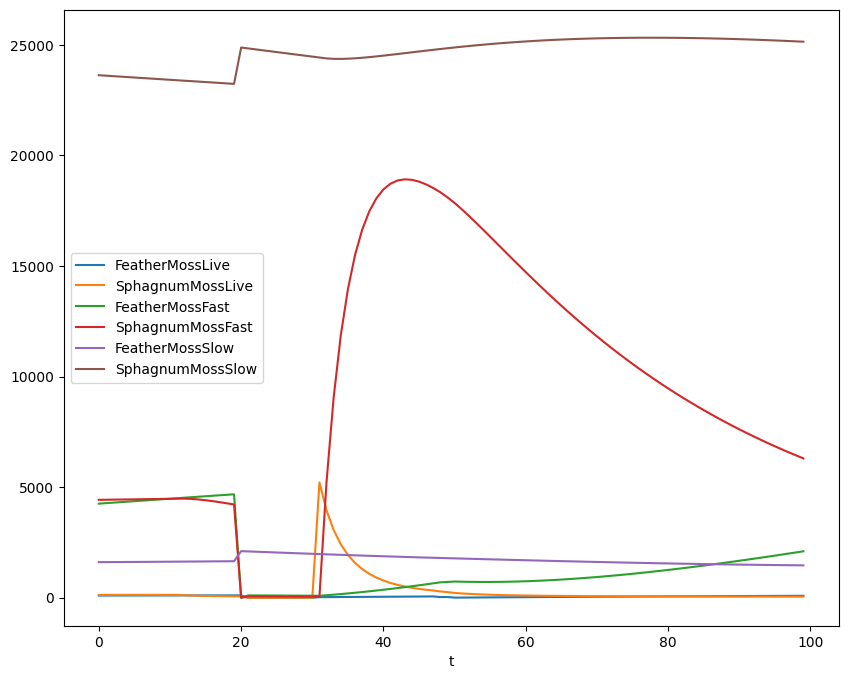

In [10]:
pools_by_timestep.groupby("t").sum()[[p.name for p in pools.ECOSYSTEM_POOLS]].plot(figsize=(10,8))

<Axes: xlabel='t'>

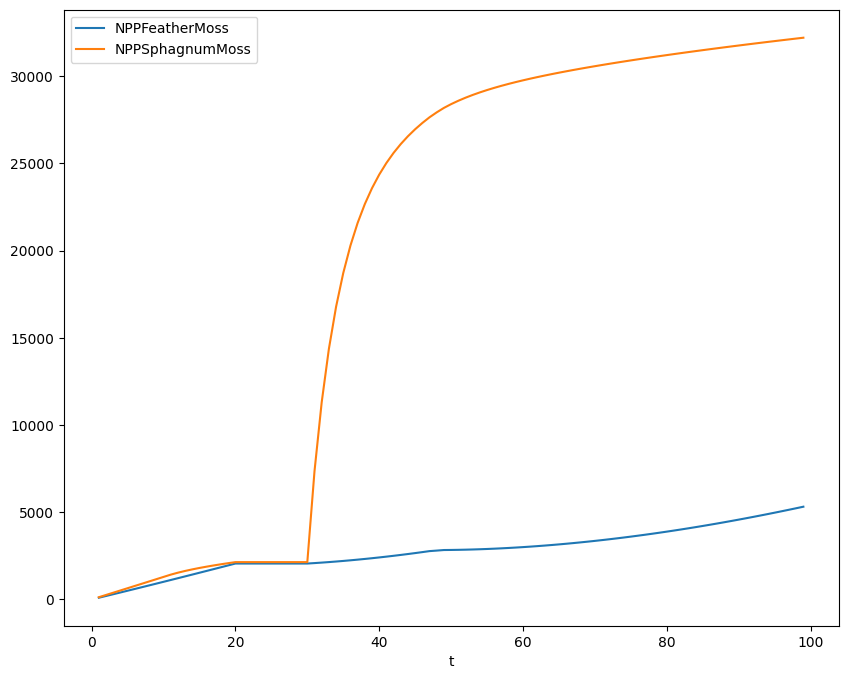

In [11]:
flux_by_timestep[["t","NPPFeatherMoss", "NPPSphagnumMoss"]].groupby("t").sum().plot(figsize=(10,8))


<Axes: xlabel='t'>

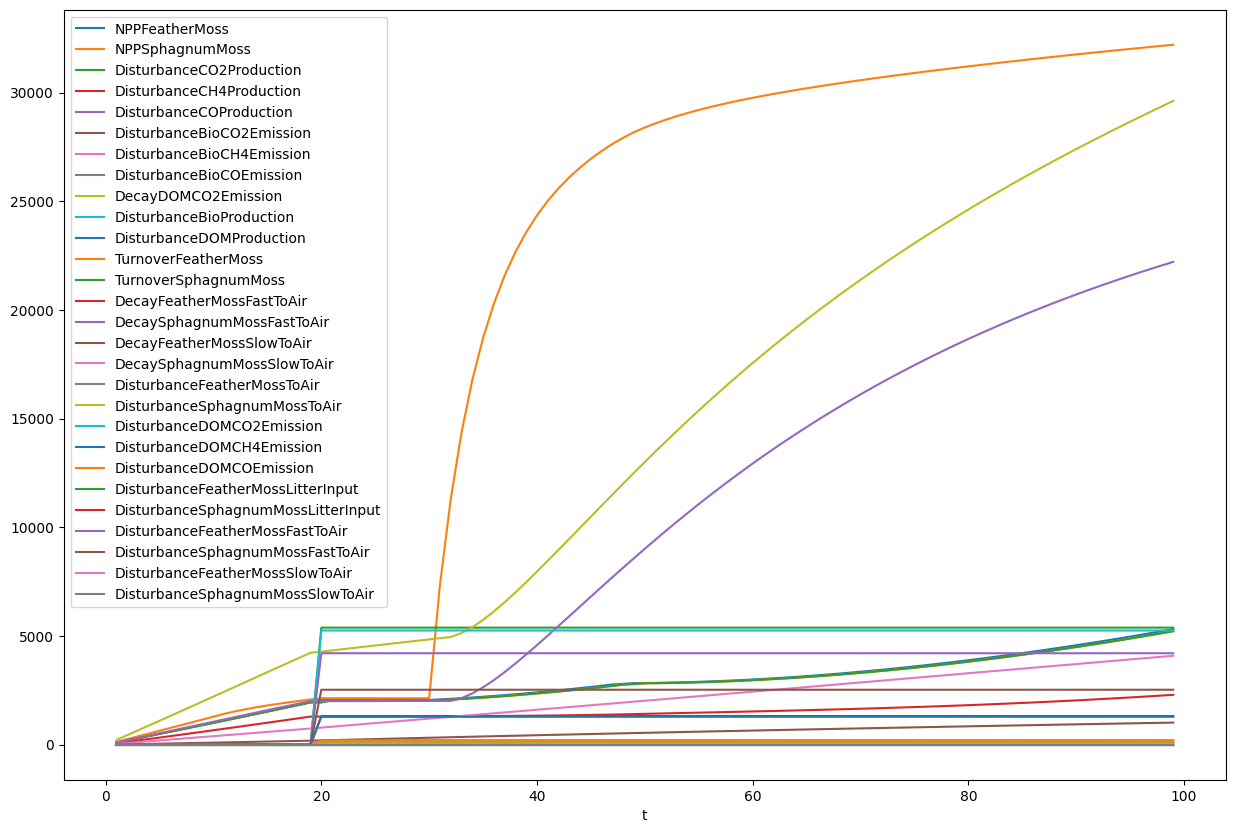

In [12]:
flux_by_timestep.groupby("t").sum().plot(figsize=(15,10))